# ИТ Криминалистика - Упражнение 1

**Тема: Извличане на характеристики от изображение**

Импортиране на необходимите библиотеки и функции на Python

In [5]:
import cv2
import matplotlib.pyplot as plt
import skimage.segmentation as seg
from skimage.filters import gabor_kernel
from skimage.feature import hog
import scipy.ndimage as nd

Четене на изображение

In [6]:
fingerprint_image = cv2.imread('100__M_Left_index_finger.bmp')
iris_image = cv2.imread('A_blue_eye.jpg')
face_image = cv2.imread('rg2.jpg')

Промяна на формат на цветно изображение

In [7]:
fingerprint_image = cv2.cvtColor(fingerprint_image, cv2.COLOR_BGR2RGB)
iris_image = cv2.cvtColor(iris_image, cv2.COLOR_BGR2RGB)
face_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB)

Визуализация на изображението

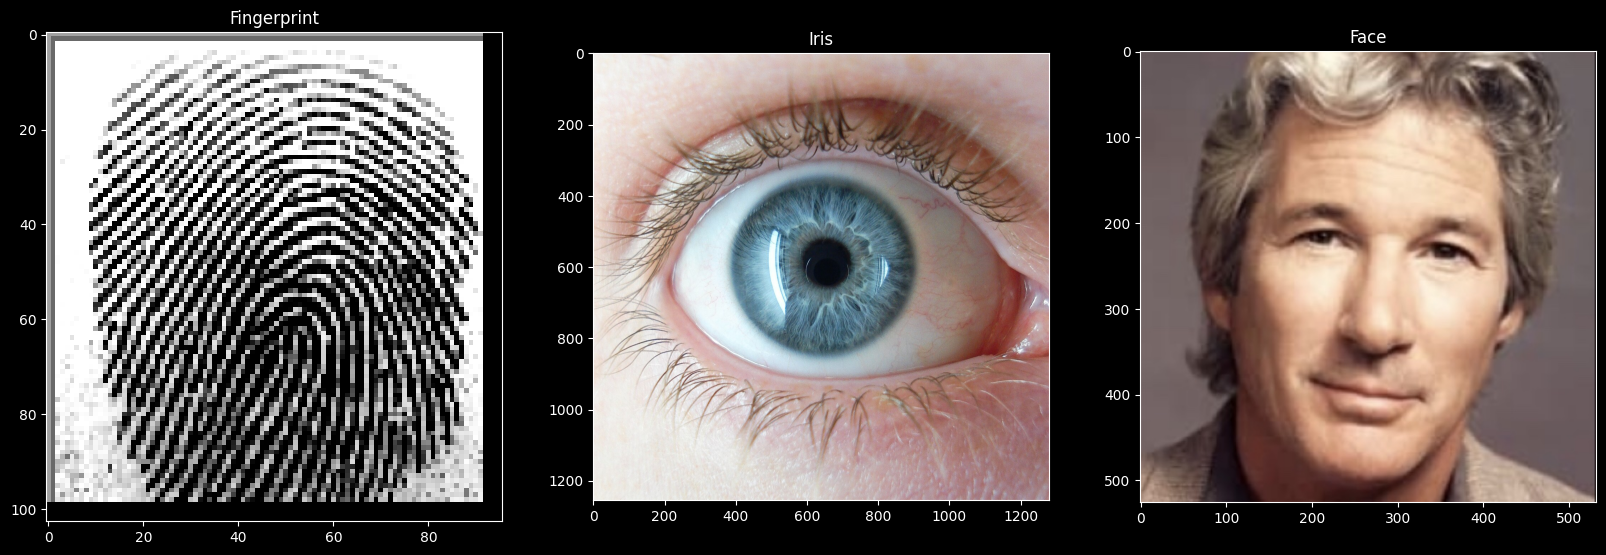

In [8]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(fingerprint_image)

axis[1].set_title('Iris')
axis[1].imshow(iris_image)

axis[2].set_title('Face')
axis[2].imshow(face_image)

Проверяване на формата на изображението (брой пиксели спрямо височина и широчина, както и брой на цветни канали)

In [9]:
fingerprint_image.shape

(103, 96, 3)

In [10]:
iris_image.shape

(1255, 1280, 3)

In [11]:
face_image.shape

(526, 532, 3)

Извеждане на хистограма на изображение

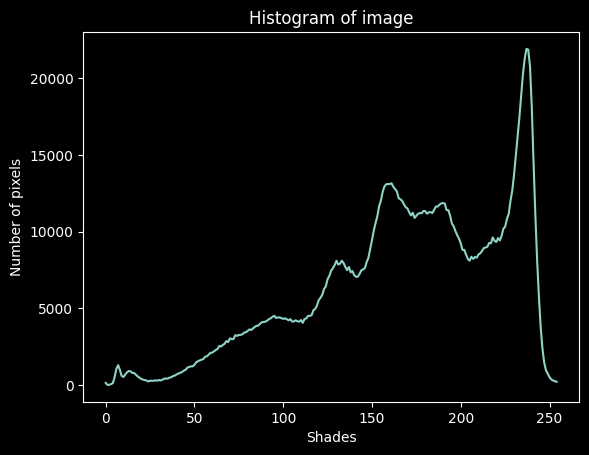

In [12]:
hist = cv2.calcHist([iris_image], [0], None, [255], [0,255])
plt.title('Histogram of image')
plt.xlabel('Shades')
plt.ylabel('Number of pixels')
plt.plot(hist)

### Контурна сегментация

**Оператор на Кани**

In [13]:
canny_iris_image = cv2.Canny(iris_image, 0, 255)

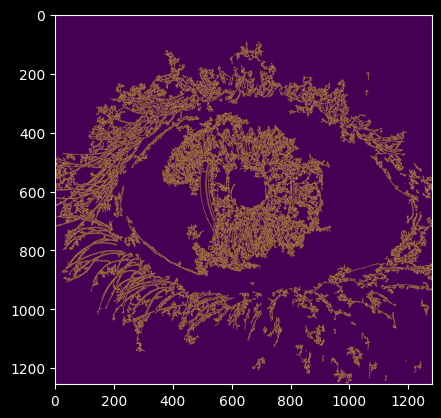

In [14]:
plt.imshow(canny_iris_image)

In [15]:
canny_face_image = cv2.Canny(face_image, 0, 255)

In [16]:
canny_fingerprint_image = cv2.Canny(fingerprint_image, 0, 255)

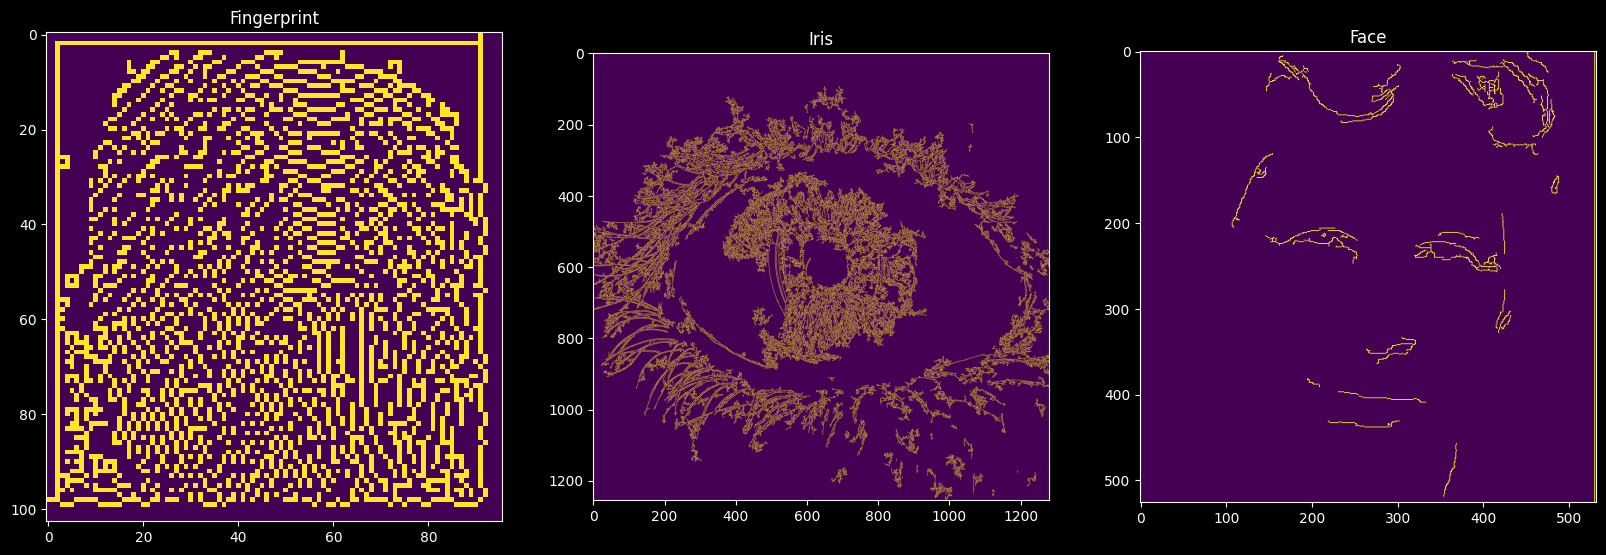

In [17]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(canny_fingerprint_image)

axis[1].set_title('Iris')
axis[1].imshow(canny_iris_image)

axis[2].set_title('Face')
axis[2].imshow(canny_face_image)

**Оператор на Лаплас и Гаус**

In [18]:
LoG_fingerprint_image = cv2.Laplacian(fingerprint_image, cv2.CV_16S)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-895..888].


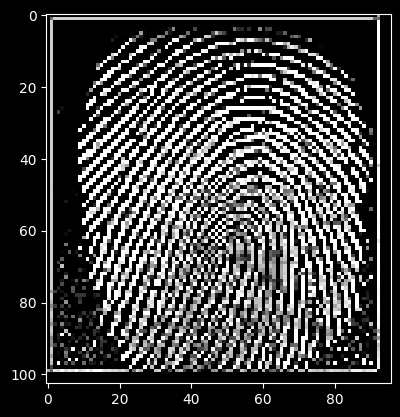

In [19]:
plt.imshow(LoG_fingerprint_image)

In [20]:
LoG_face_image = cv2.Laplacian(face_image, cv2.CV_16S)

In [21]:
LoG_iris_image = cv2.Laplacian(iris_image, cv2.CV_16S)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-895..888].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-492..350].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-72..168].


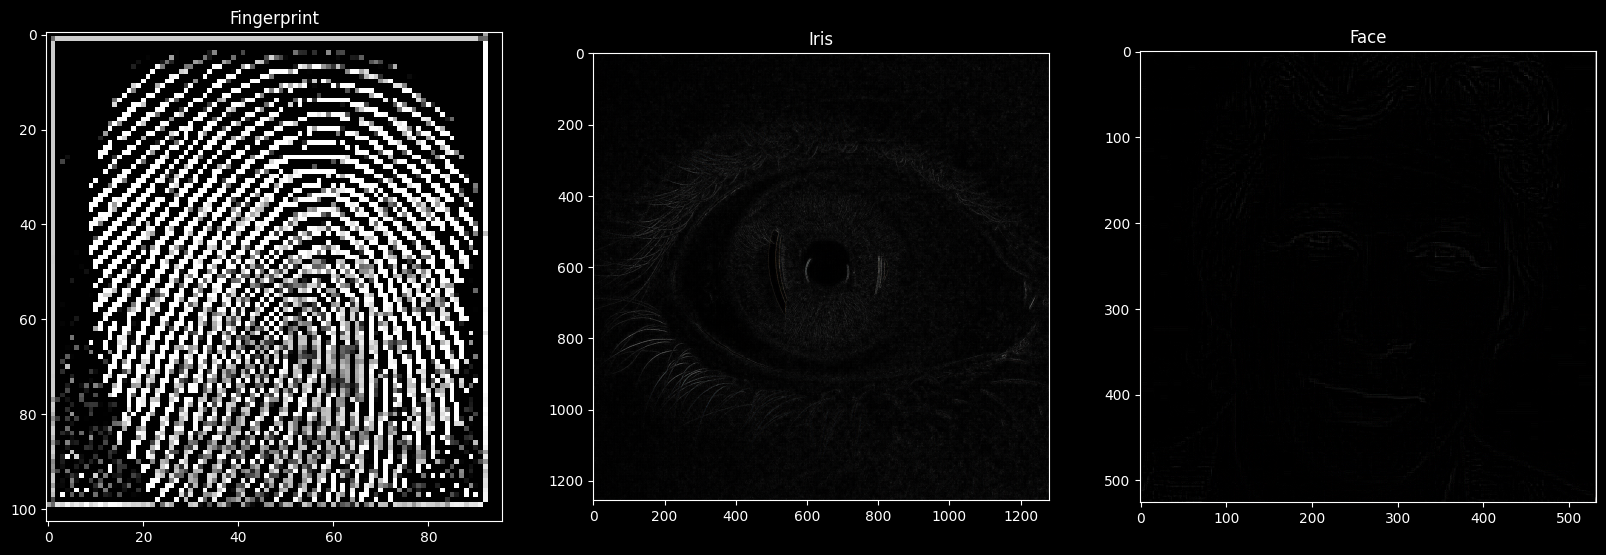

In [22]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(LoG_fingerprint_image)

axis[1].set_title('Iris')
axis[1].imshow(LoG_iris_image)

axis[2].set_title('Face')
axis[2].imshow(LoG_face_image)

**Оператор на Собел**

In [23]:
sobel_fingerprint_image = cv2.Sobel(fingerprint_image, cv2.CV_16S, 1,1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-510..510].


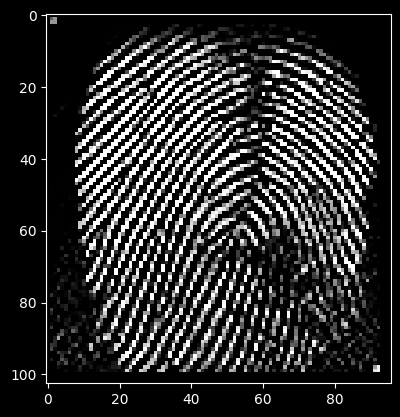

In [24]:
plt.imshow(sobel_fingerprint_image)

In [25]:
sobel_iris_image = cv2.Sobel(iris_image, cv2.CV_16S, 1,1)

In [26]:
sobel_face_image = cv2.Sobel(face_image, cv2.CV_16S, 1,1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-510..510].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-386..314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61..47].


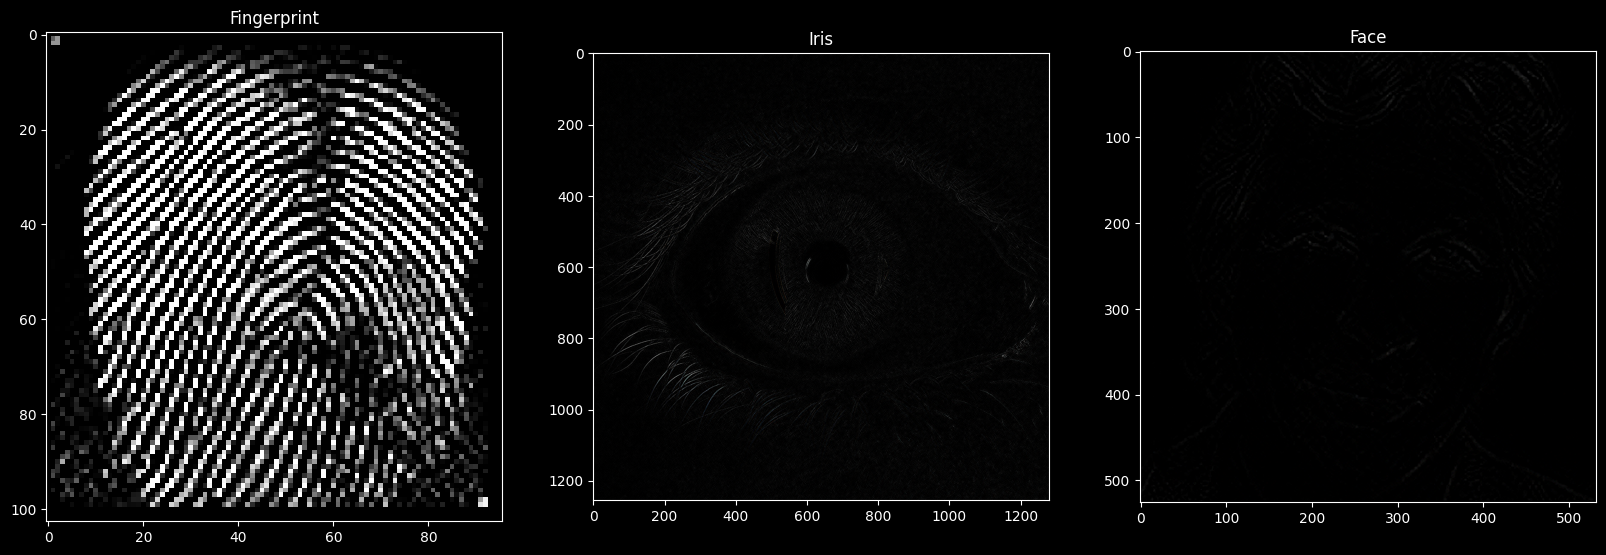

In [27]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(sobel_fingerprint_image)

axis[1].set_title('Iris')
axis[1].imshow(sobel_iris_image)

axis[2].set_title('Face')
axis[2].imshow(sobel_face_image)

### Областна сегментация

**Сегментация чрез представяне на изображението в бинарен вид**

In [28]:
threshold_1, thresh_1 = cv2.threshold(fingerprint_image, 100, 255, cv2.THRESH_BINARY)

In [29]:
threshold_2, thresh_2 = cv2.threshold(iris_image, 100, 255, cv2.THRESH_BINARY)

In [30]:
threshold_3, thresh_3 = cv2.threshold(face_image, 100, 255, cv2.THRESH_BINARY)

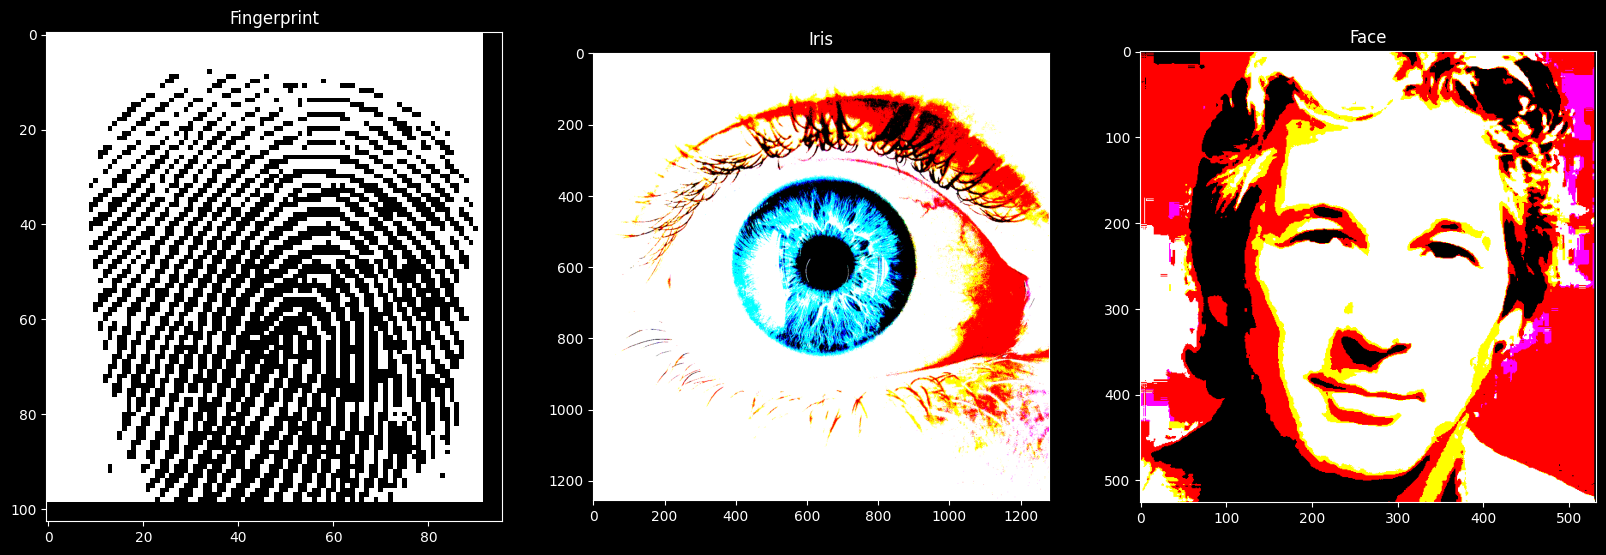

In [31]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(thresh_1)

axis[1].set_title('Iris')
axis[1].imshow(thresh_2)

axis[2].set_title('Face')
axis[2].imshow(thresh_3)

**Simple Linear Iterative Clustering**

In [32]:
fingerprint_image_slic = seg.slic(fingerprint_image, n_segments=100)

In [33]:
iris_image_slic = seg.slic(iris_image, n_segments=100)

In [34]:
face_image_slic = seg.slic(face_image, n_segments=100)

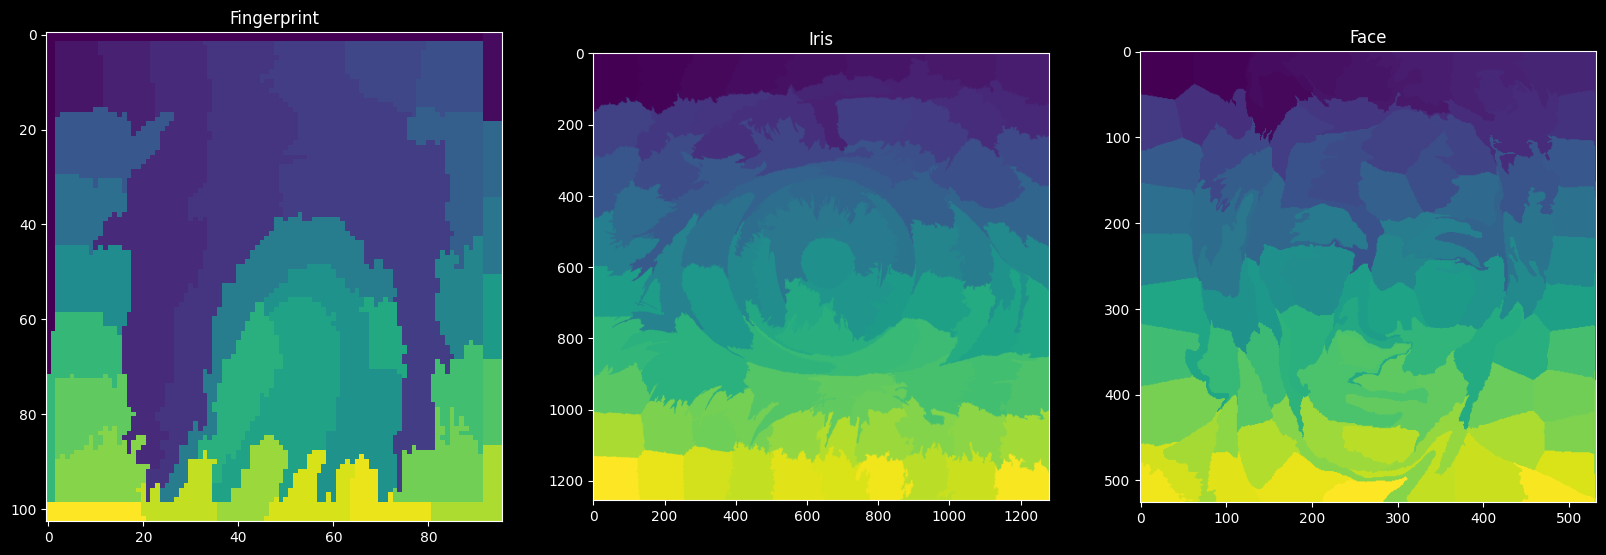

In [35]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(fingerprint_image_slic)

axis[1].set_title('Iris')
axis[1].imshow(iris_image_slic)

axis[2].set_title('Face')
axis[2].imshow(face_image_slic)

### Филтър на Габор

Създаване на филтър, с честота 0.25 Hz и ъгъл от 0.78 радиана (45 градуса)

In [36]:
kernel = gabor_kernel(frequency = 0.25, theta = 0.78)

Проверка на размер на филтъра

In [37]:
kernel.shape

(11, 11)

Преобразуване на изображението от цветно в черно-бяло

In [38]:
gray_fingerprint_image = cv2.cvtColor(fingerprint_image, cv2.COLOR_BGR2GRAY)

In [39]:
gray_iris_image = cv2.cvtColor(iris_image, cv2.COLOR_BGR2GRAY)

In [40]:
gray_face_image = cv2.cvtColor(face_image, cv2.COLOR_BGR2GRAY)

Конволюция на изображението и филтър на Габор

In [41]:
gabor_fingerprint_image = nd.convolve(gray_fingerprint_image, kernel)

In [42]:
gabor_iris_image = nd.convolve(gray_iris_image, kernel)

In [43]:
gabor_face_image = nd.convolve(gray_face_image, kernel)

TypeError: Image data of dtype complex64 cannot be converted to float

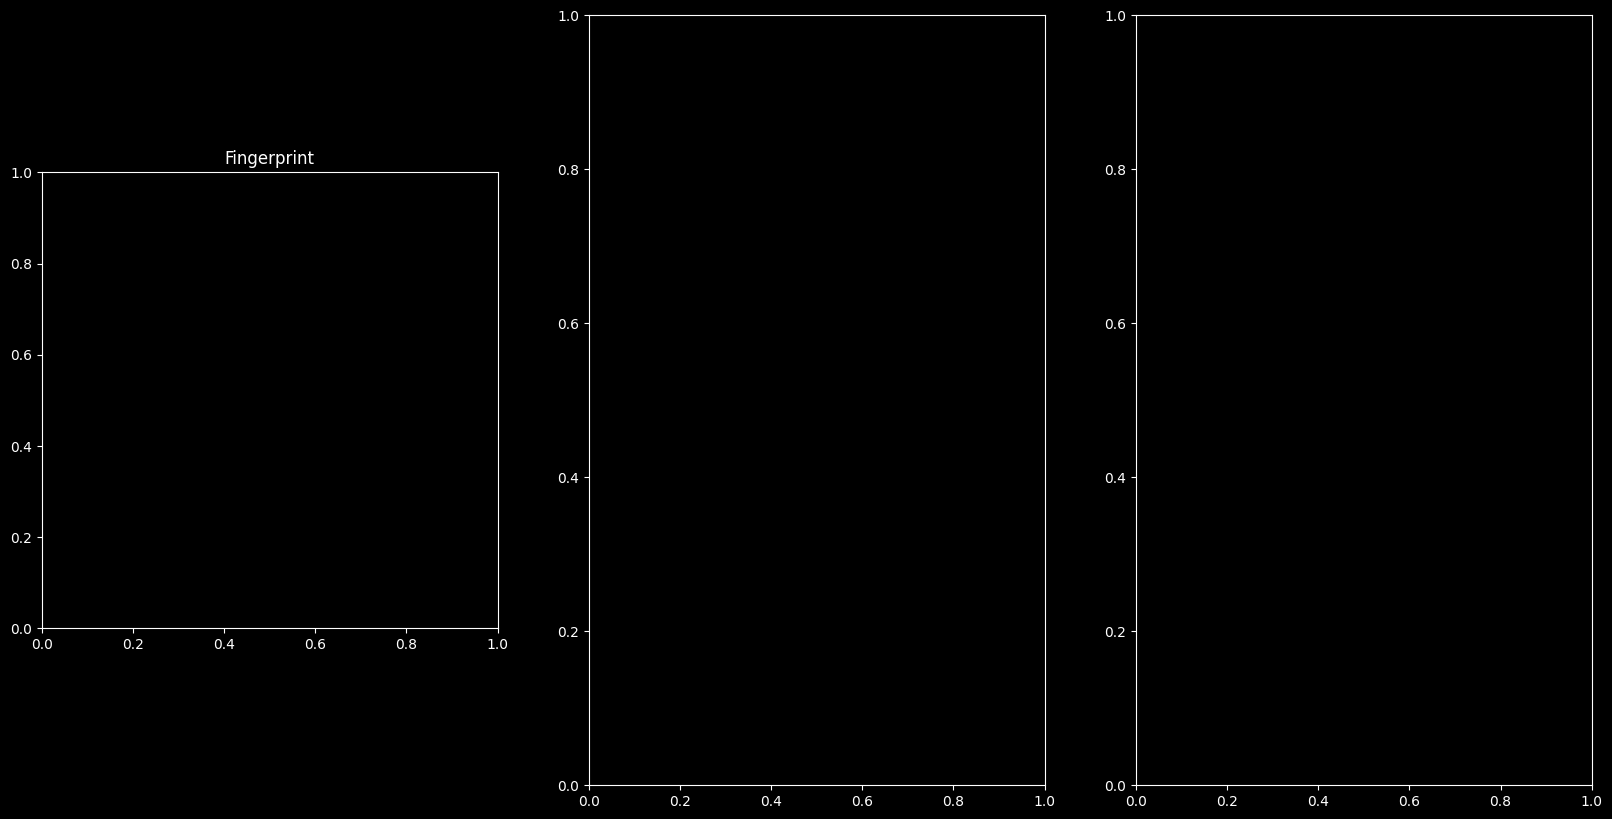

In [44]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(gabor_fingerprint_image)

axis[1].set_title('Iris')
axis[1].imshow(gabor_iris_image)

axis[2].set_title('Face')
axis[2].imshow(gabor_face_image)

### Хистограма на Ориентирани градиенти

In [ ]:
hog_descriptor_1, hog_image_1 = hog(fingerprint_image, orientations = 9, visualize = True, multichannel = True)

In [ ]:
hog_descriptor_2, hog_image_2 = hog(iris_image, orientations = 9, visualize = True, multichannel = True)

In [ ]:
hog_descriptor_3, hog_image_3 = hog(face_image, orientations = 9, visualize = True, multichannel = True)

In [ ]:
fig, axis = plt.subplots(nrows = 1, ncols = 3, figsize=(20,10))
axis[0].set_title('Fingerprint')
axis[0].imshow(hog_image_1)

axis[1].set_title('Iris')
axis[1].imshow(hog_image_2)

axis[2].set_title('Face')
axis[2].imshow(hog_image_3)